# End to End With the Advertising Dataset

- **Dataset** : This Advertising dataset, which records the money spent on TV, Radio, and Newspaper advertising.

## Our Tasks: 
    1. Loading and inspecting the data
    2. Descriptive stastics
    3. EDA and visualisation
    4. Checking assumptions
    5. Preparing data for modelling
    6. Building model (simple and multiple linear regression)
    7. Evaluating the model
    8. Residual analysis
    9. Interpreting the coefficients
    

# 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 2. Load the Data


In [2]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
df = pd.read_csv(url, index_col=0)

In [3]:
df.head()

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


# 3. Data Description

In [4]:
# data types and null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [5]:
# check for missing values
df.isnull().sum()

TV           0
radio        0
newspaper    0
sales        0
dtype: int64

In [7]:
# describe statistics
df.describe().round(2)

,TV,radio,newspaper,sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,14.02
std,85.85,14.85,21.78,5.22
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,10.38
50%,149.75,22.90,25.75,12.90
75%,218.82,36.52,45.10,17.40
max,296.40,49.60,114.00,27.00


# 4. EDA and Visualization

### 4.1 Distribution of each variable

**Histogram with KDE for each features to check distribution  shape and potential outliers**


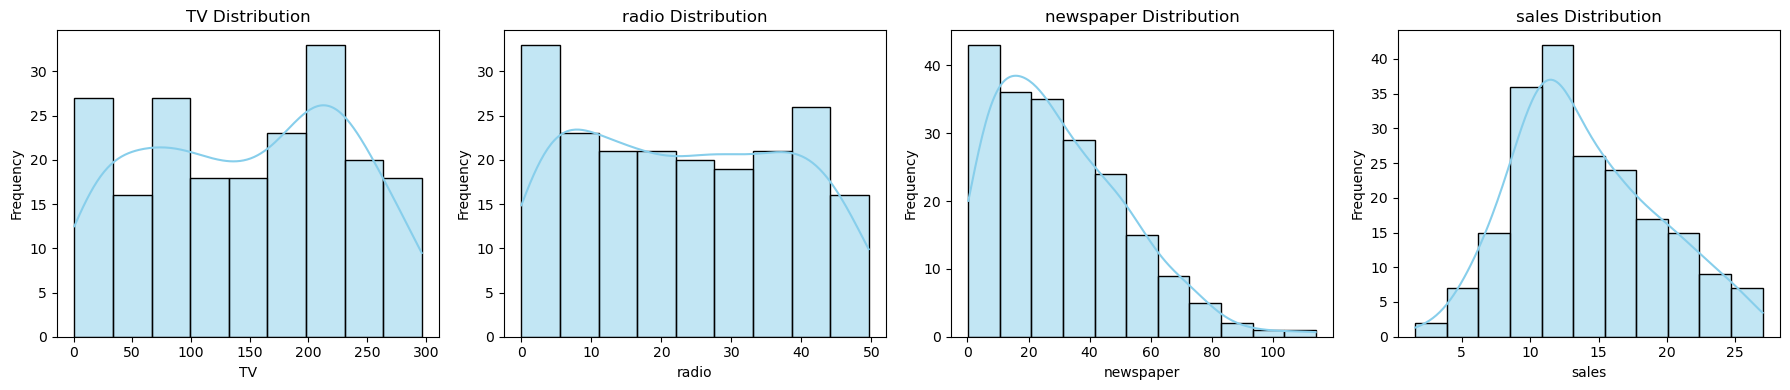

In [9]:
fig, axes = plt.subplots(1,4, figsize=(18,4))

for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# 4.2 Boxplots - Spotting outliers

**Boxplots are the fastest way to check for outliers. Any point sitting far outside the wisher is outlier**

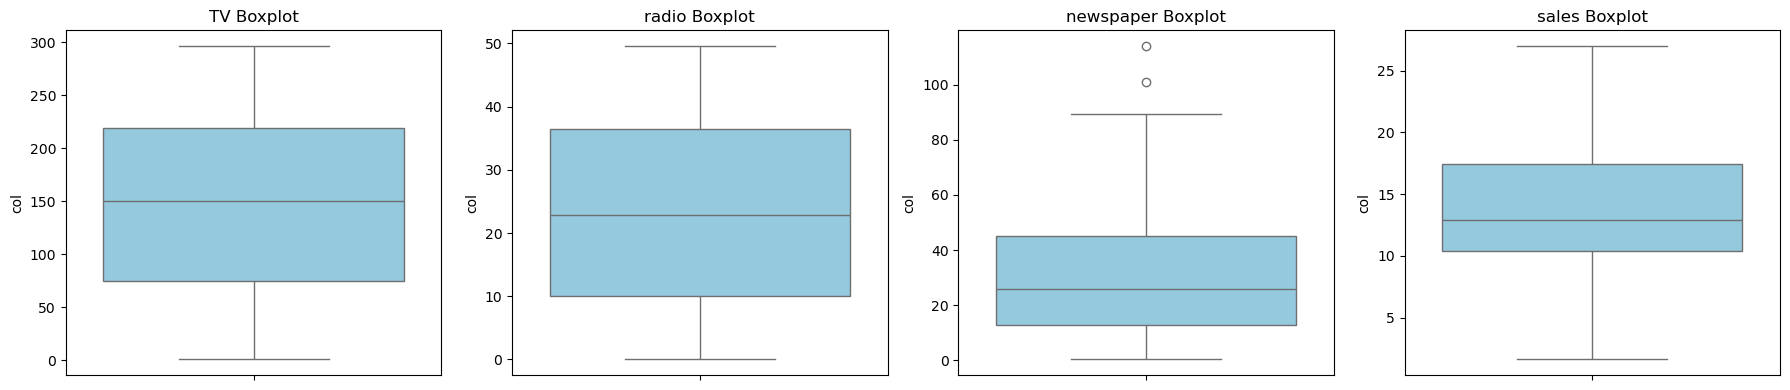

In [11]:
fig, axes = plt.subplots(1,4, figsize=(18,4))
for i, col in enumerate(df.columns):
    sns.boxplot(y= df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'{col} Boxplot')
    axes[i].set_ylabel('col')

plt.tight_layout()
plt.show()


# 4.3 Scatter plots - Features vs Sales
**This can the most important visualization step.**

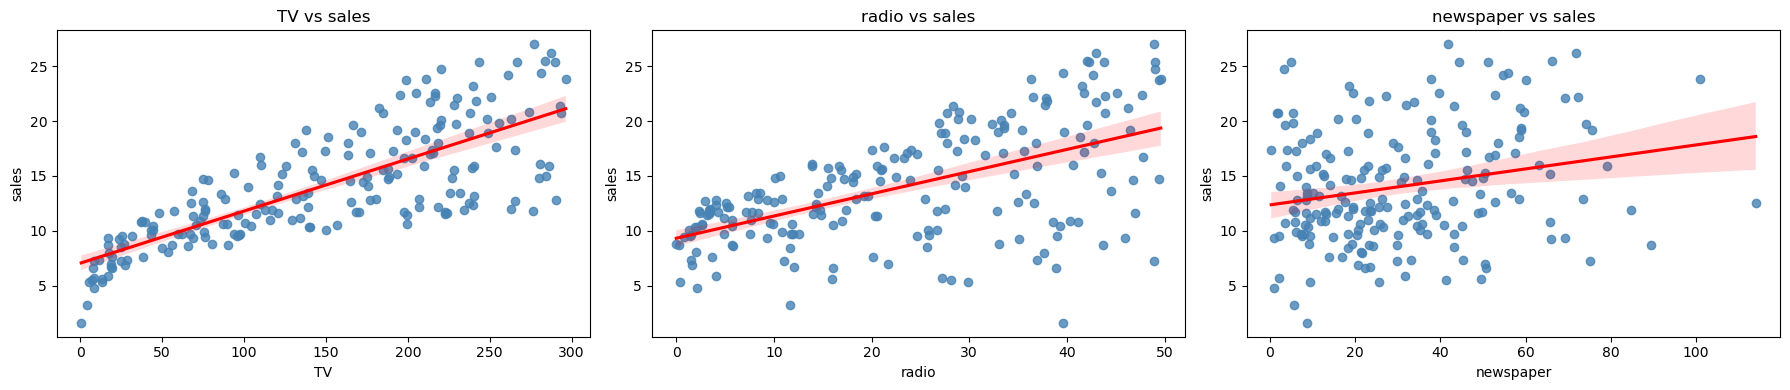

In [14]:
#scatter plots with regression lines for each feature vs target
features = df.columns[:-1] # all columns except for last one(sales: which is target)
target = df.columns[-1] # the last column (Sales)

fig, axes = plt.subplots(1, 3, figsize=(18,4))
for i, feature in enumerate(features):
    sns.regplot(x=df[feature], y=df[target], ax=axes[i], color='steelblue', line_kws={'color':'red'})
    # scatterplot + regression line
    axes[i].set_title(f'{feature} vs {target}' )
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(target)

plt.tight_layout()
plt.show()

# 4.4 Correlation matrix
**The correlation matrix quantifies what scatterplots showed.**

              TV  radio  newspaper  sales
TV         1.000  0.055      0.057  0.782
radio      0.055  1.000      0.354  0.576
newspaper  0.057  0.354      1.000  0.228
sales      0.782  0.576      0.228  1.000


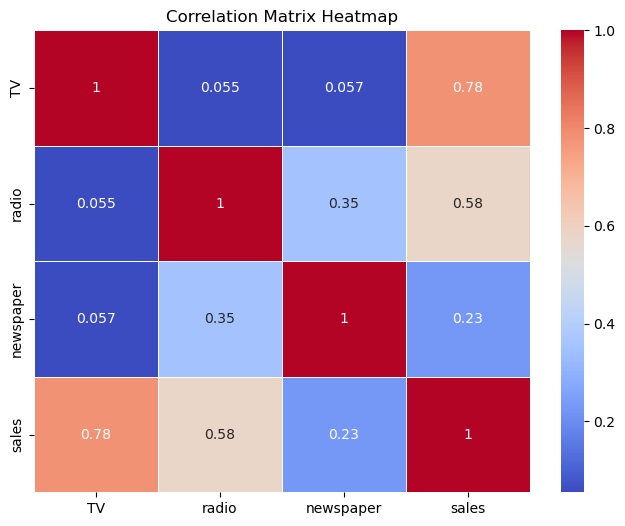

In [16]:
# correlation matrix heatmap plot
corr = df.corr().round(3)
print(corr)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidth=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

# 5 Preparing data for Modelling
**We will seperate the features(X) from the target (y), then split into training and test sets. Generalize to unseen data.**

In [18]:
# define features and target
X = df[['TV', 'radio', 'newspaper']]
y = df['sales']


## 70-30 train-test split with a fixed random state for reproducibility
### Why do we need this?
In machine learning, you need to:

- Train your model on some data (so it learns patterns)
- Test your model on NEW data it hasn't seen (to check if it actually learned general patterns, not just memorized)

In [19]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# test_size=0.3 (30% for training, 70% for testing)
# random_state:Ensures you get the same random split every time you run the code
# A split means dividing your dataset into different groups - specifically, which rows go to training and which go to testing


# 6. Building the Model
**We will start with a Simple Linear Regression (using only TV at first, because it is the strongest as we have visualize before)

# 6.1 Simple Linear Regression(TV only)

In [20]:
slr = LinearRegression() # it comes from skit learn
slr.fit(X_train[['TV']], y_train)
y_pred_slr = slr.predict(X_test[['TV']])


In [24]:
print(y_pred_slr)
print(y_test)

[14.81785392 16.30754437 20.83230507  7.78243112 17.46309864 10.72468577
 17.30067133  9.55984994 17.56055502 15.36546598  8.7013056   9.84757831
 18.12208943  7.49006196 13.71334823 15.13806775  7.57823679 16.40964153
 10.73396733 18.25667206 17.89005042 10.38590882  9.00295631 18.88317738
 10.44159818  9.72227724 17.14752559 13.70406667 11.28622018  7.62928537
 16.5117387  10.45087974 16.46997167  8.02375169 20.26612989 18.2937983
  9.48095667 19.94127527 12.67845424  8.51567439 12.62276488 15.45364081
  9.2396361  10.1306659  17.63480751  9.01223787 10.51585066 14.07532908
 12.09371593 10.78037513 10.86854996 15.05453371  7.64320771  7.60144069
 10.78501591 13.24462943 10.64579251 20.68380011  8.14905275 16.40964153]
96     16.9
16     22.4
31     21.4
159     7.3
129    24.7
116    12.6
70     22.3
171     8.4
175    11.5
46     14.9
67      9.5
183     8.7
166    11.9
79      5.3
187    10.3
178    11.7
57      5.5
153    16.6
83     11.3
69     18.9
125    19.7
17     12.5
149   

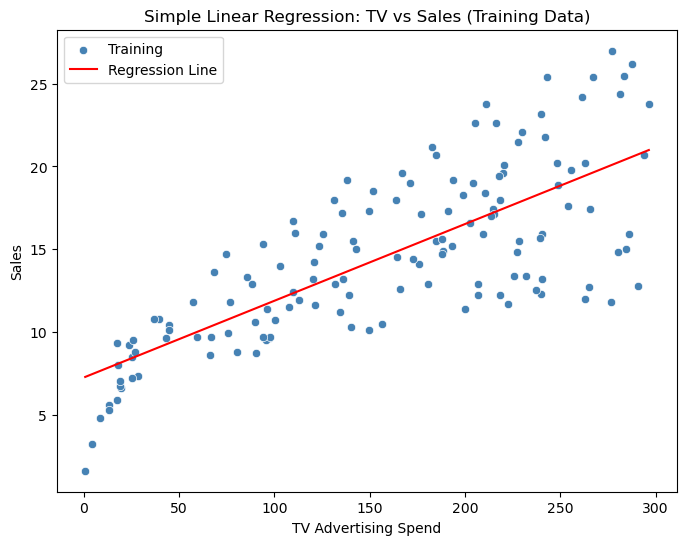

In [23]:
# Visualise the simple regression line on the training data
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_train['TV'], y=y_train, color='steelblue', label='Training')
sns.lineplot(x=X_train['TV'], y=slr.predict(X_train[['TV']]), color='red', label='Regression Line')
plt.title('Simple Linear Regression: TV vs Sales (Training Data)')
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [35]:
# Evaluate the simple model on the test set
mse_slr = mean_squared_error(y_test, y_pred_slr)
r2_slr = r2_score(y_test, y_pred_slr)
mae_slr = mean_absolute_error(y_test, y_pred_slr)

print("--- Simple LR -- Test set performance ---")
print(f"R-squared : {r2_slr:.4f}")
print(f"MAE       : {mae_slr:.4f}")
print(f"RMSE      : {np.sqrt(mse_slr):.4f}")




--- Simple LR -- Test set performance ---
R-squared : 0.6714
MAE       : 2.2759
RMSE      : 2.9952


In [36]:
# SIMPLE LINEAR REGRESSION (only TV advertising)
# What it does: Uses ONLY TV ad spending to predict sales
# How accurate: Explains 67% of sales patterns (R² = 0.67)
# Typical mistake: Predictions are off by about 2.28 units (MAE)
# Big mistakes: Sometimes off by up to 3.00 units (RMSE)
# Problem: Ignores radio and newspaper ads completely

# 6.2 Multiple Linear Regression (TV + Radio + Newspaper)


In [28]:
# multiple linear regression using all theree features
mlr = LinearRegression()
mlr.fit(X_train, y_train)
y_pred_mlr = mlr.predict(X_test)

# the learned coefficients and intercept of the muliple linear regression model
print("----- Multiple Linear REgression Coefficients ---")
print(f"Intercept (beta_0) : {mlr.intercept_:.4f}")
for i, col in enumerate(X.columns):
    print(f"Coefficient for {col} (beta_{i+1}): {mlr.coef_[i]:.4f}")


#Intercept = y-intercept = bias (the baseline)
#Coefficients = weights = slopes (how much each feature influences the prediction)
# Intercept (beta_0) = 2.7089    → This is the y-intercept (bias)
# Coefficient (beta_1,2,3)       → These are weights (slopes)

----- Multiple Linear REgression Coefficients ---
Intercept (beta_0) : 2.7089
Coefficient for TV (beta_1): 0.0441
Coefficient for radio (beta_2): 0.1993
Coefficient for newspaper (beta_3): 0.0069


# 7. Model Evaluation
**We evaluate the multiple regression model on the held-out test set.**

In [34]:
# Multiple LR - Test set Performance
y_pred_mlr = mlr.predict(X_test)
mse_mlr = mean_squared_error(y_test, y_pred_mlr)
r2_mlr = r2_score(y_test, y_pred_mlr)
mae_mlr = mean_absolute_error(y_test, y_pred_mlr)


print("--- Multiple LR -- Test set performance ---")
print(f"R-squared : {r2_mlr:.4f}")
print(f"MAE       : {mae_mlr:.4f}")
print(f"RMSE      : {np.sqrt(mse_mlr):.4f}")

--- Multiple LR -- Test set performance ---
R-squared : 0.8609
MAE       : 1.5117
RMSE      : 1.9485


In [37]:
# MULTIPLE LINEAR REGRESSION (TV + Radio + Newspaper)
# What it does: Uses ALL THREE ad channels together to predict sales
# How accurate: Explains 86% of sales patterns (R² = 0.86) - MUCH better!
# Typical mistake: Predictions are off by only 1.51 units (MAE)
# Big mistakes: Rarely off by more than 1.95 units (RMSE)
# Key insight: Radio is strongest (0.20), Newspaper is weakest (0.01)
# Why better: Captures radio's huge impact that simple model missed

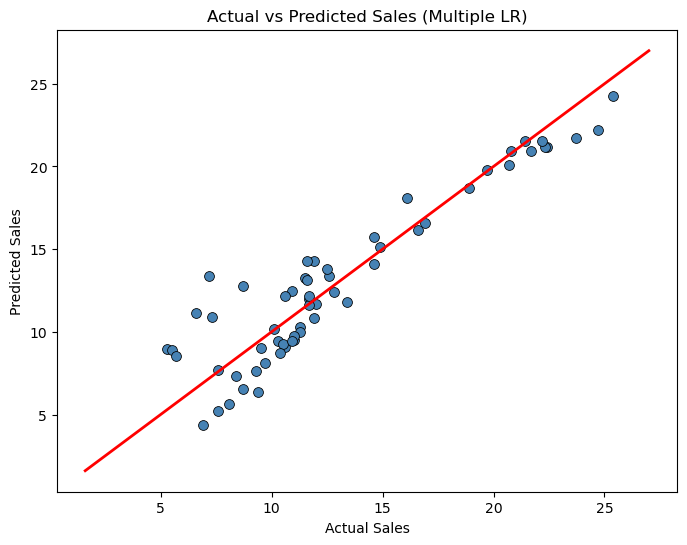

In [40]:
# Actual vs Predicted Sales (Multiple LR) plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_mlr, color='steelblue', edgecolor='black', s=50)
sns.lineplot(x=[y.min(), y.max()], y=[y.min(), y.max()], color='red', linewidth=2)
plt.title('Actual vs Predicted Sales (Multiple LR)')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.show()

/tmp/ipykernel_9231/593784115.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X.columns, y=mlr.coef_, palette='viridis')


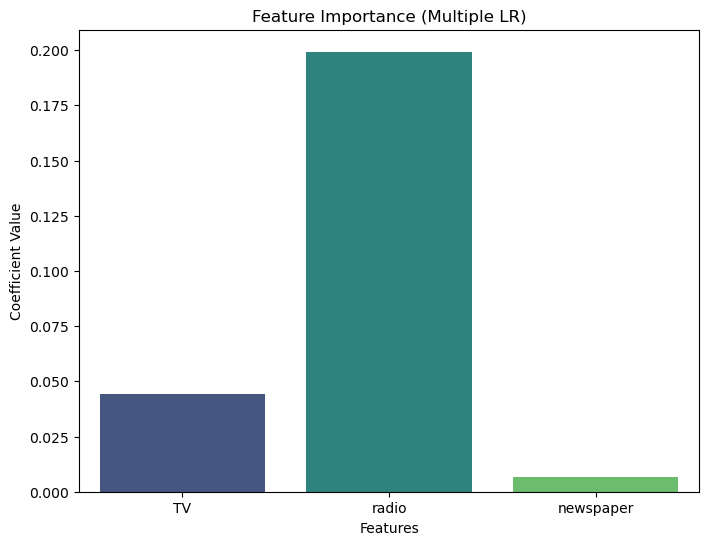

In [41]:
# coefficient bar chart plot to visually compare the relative importance
plt.figure(figsize=(8,6))
sns.barplot(x=X.columns, y=mlr.coef_, palette='viridis')
plt.title('Feature Importance (Multiple LR)')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.show()
